Nama  : Alfarell Muchamad Yuwanto

NIM   : 240401010037

Kelas : IF401

# Hands On Pertemuan 9 - Prediksi Diagnosis 

##  Load & EDA Singkat

In [6]:
from sklearn.datasets import load_breast_cancer 
import pandas as pd 
  
data = load_breast_cancer() 
X = pd.DataFrame(data.data, columns=data.feature_names) 
y = data.target  # 0=malignant, 1=benign 
  
print('Shape:', X.shape) 
print('Distribusi target:') 
print(pd.Series(y).value_counts(normalize=True).round(3)) 

Shape: (569, 30)
Distribusi target:
1    0.627
0    0.373
Name: proportion, dtype: float64


## Preprocessing

In [7]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
  
X_train, X_test, y_train, y_test = train_test_split( 
    X, y, test_size=0.2, random_state=42, stratify=y) 
  
scaler = StandardScaler() 
X_train_s = scaler.fit_transform(X_train) 
X_test_s  = scaler.transform(X_test) 

## Latih Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression 
  
log_model = LogisticRegression(max_iter=5000) 
log_model.fit(X_train_s, y_train) 
y_pred_log = log_model.predict(X_test_s) 
  
coef_df = pd.DataFrame({'Fitur': X.columns, 
    'Koefisien': log_model.coef_[0] 
    }).sort_values('Koefisien', key=abs, ascending=False) 
print(coef_df.head())

                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


## Latih Decision Tree

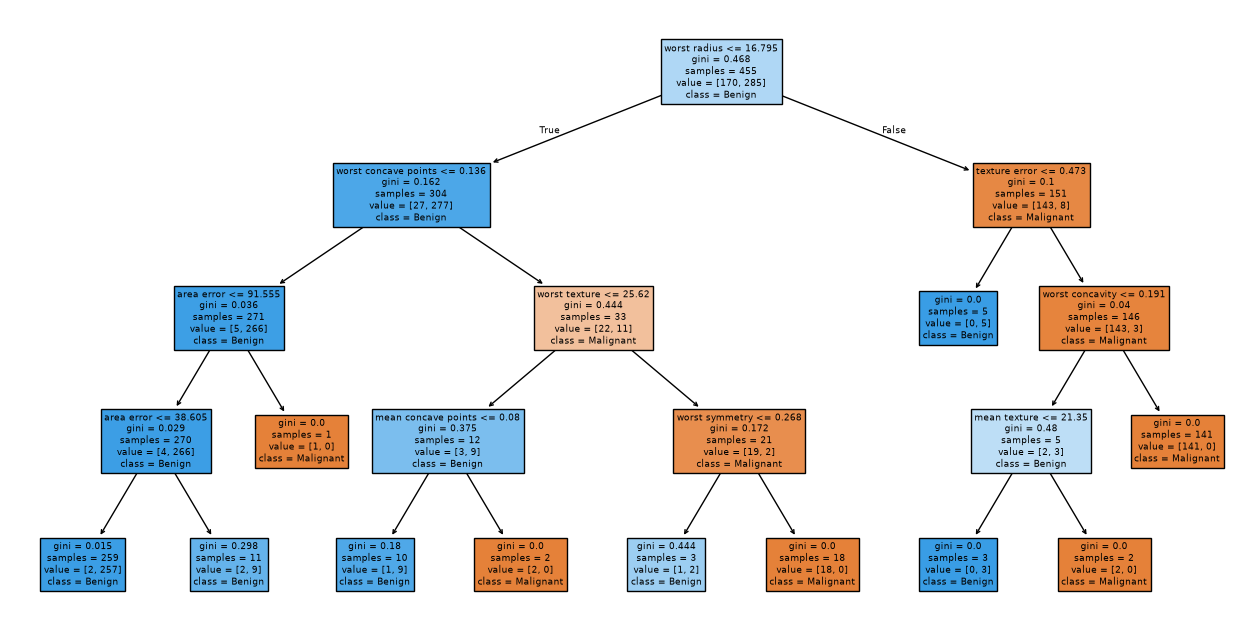

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree 
import matplotlib.pyplot as plt 
  
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42) 
tree_model.fit(X_train, y_train) 
y_pred_tree = tree_model.predict(X_test)
plt.figure(figsize=(16, 8)) 
plot_tree(tree_model, feature_names=X.columns, class_names=['Malignant','Benign'], filled=True) 
plt.show()

## Evaluasi & Bandingkan 

In [10]:
from sklearn.metrics import (confusion_matrix, 
accuracy_score, precision_score, 
recall_score, f1_score) 
for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]: 
  print(f"\n=== {name} ===") 
  print(confusion_matrix(y_test, y_pred)) 
  print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}") 
  print(f"Precision: {precision_score(y_test, y_pred):.3f}") 
  print(f"Recall   : {recall_score(y_test, y_pred):.3f}") 
  print(f"F1-Score : {f1_score(y_test, y_pred):.3f}") 


=== Logistic Regression ===
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-Score : 0.986

=== Decision Tree ===
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall   : 0.944
F1-Score : 0.951


## Kesimpulan

- **Apa yang dipelajari:** Melatih, mengevaluasi, dan membandingkan dua model klasifikasi supervised learning (`Logistic Regression` dan `Decision Tree Classifier`) pada dataset diagnosis kanker payudara (*Breast Cancer Wisconsin*), serta memahami metrik evaluasi klasifikasi (Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score).
- **Temuan utama:** Model `Logistic Regression` dengan penskalaan fitur (`StandardScaler`) memberikan performa yang lebih unggul dengan akurasi 98.2% dan F1-Score 98.6% dibandingkan `Decision Tree` (akurasi 93.9% dan F1-Score 95.1%). Fitur-fitur seperti `worst texture`, `radius error`, dan `worst concave points` menjadi prediktor paling berpengaruh dalam klasifikasi sel tumor/kanker.
- **Keterbatasan / Pertanyaan:** `Decision Tree` dengan kedalaman tertentu (`max_depth=4`) lebih mudah diinterpretasikan secara visual (*white-box*), namun rentan mengalami *overfitting* jika tidak dibatasi. Untuk data medis berdimensi tinggi, kombinasi model ensemble (seperti Random Forest) atau regularisasi pada Logistic Regression (L1/L2) dapat dieksplorasi lebih lanjut.